# Main Experiment Notebook
This notebook runs the full pipeline step by step.

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


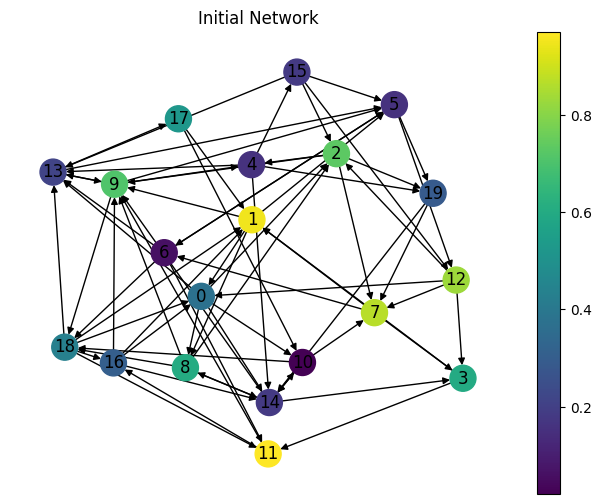

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:

import sys, os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('../'))

from src.graph import create_graph
from src.visualization import plot_graph
from src.experiments import test_multiple_messages, propagate
from src.optimization import search_best_message, lightweight_ppo

# Step 1: Create graph
G, opinions = create_graph()

# Step 2: Visualize
plot_graph(G, opinions, title='Initial Network')

# Step 3: Test prompts
prompts = [
    "IRAN WAR and Trump",
    "Climate action is",
    "The future of clean energy is",
    "Our community should support",
    "Public policy must prioritize"
]

results_df = test_multiple_messages(G, opinions, prompts)

print("\nMultiple Message Comparison:")
print(results_df[["Post Text","Post Number", "Prompt", "Sentiment Score", "Engagement Score"]])

best_post_row = results_df.sort_values("Engagement Score", ascending=False).iloc[0]

plot_graph(
    G,
    best_post_row["Updated Opinions"],
    activated_nodes=best_post_row["Activated Nodes"],
    title="Best Generated Message Diffusion"
)


# Step 4: Brute-force search
best_value, best_score, best_nodes, best_updated = search_best_message(G, opinions)

print("\nBest Message Value:", round(best_value, 3))
print("Best Engagement:", best_score)

plot_graph(
    G,
    best_updated,
    activated_nodes=best_nodes,
    title="Best Numeric Message Diffusion"
)

# Step 5: PPO optimization
print(lightweight_ppo(G, opinions))

ppo_message, ppo_history = lightweight_ppo(G, opinions)

print("\nPPO Optimization History:")
print(ppo_history)

ppo_score, ppo_updated, ppo_nodes = propagate(G, opinions, ppo_message)

plot_graph(
    G,
    ppo_updated,
    activated_nodes=ppo_nodes,
    title="PPO Optimized Message Diffusion"
)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Post Number"].astype(str), results_df["Engagement Score"])
plt.xlabel("Post Number")
plt.ylabel("Engagement Score")
plt.title("Engagement Scores for Generated Posts")
plt.show()